# L63 Speedup: Discretizer + Dirac vs EnKF + NUTS

This tutorial compares two approaches for inferring the Lorenz 63 parameter $\rho$ when we have **fully observed** states with **low observation noise** and **high-frequency measurements** (so observations approach exact state measurements, i.e. Dirac):

1. **EnKF + NUTS** (filtering-based continuous-time): Uses `FilterBasedMarginalLogLikelihood` with EnKF to approximate the marginal likelihood, then NUTS for MCMC.

2. **Discretizer + DiscreteTimeSimulator + Dirac + NUTS**: Discretizes the SDE (Euler-Maruyama), treats observations as exact states (`DiracIdentityObservation`), and runs NUTS directly. This avoids filtering entirely and is typically much faster.

We report timing and posteriors for both approaches.

## Setup and Model

We use the Lorenz 63 system with:
- **Fully observed**: $y_t = x_t$ (or $y_t \approx x_t$ with low noise)
- **Low noise**: $R = 0.01^2 I_3$ (approaches Dirac)
- **High-frequency**: $\Delta t = 0.01$ over $[0, 20]$
- **Learn**: $\rho \sim \mathcal{U}(10, 40)$

In [ ]:
import time

import arviz as az
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx.dynamical_models import DynamicalModel, ContinuousTimeStateEvolution
from dynestyx.filters import FilterBasedMarginalLogLikelihood
from dynestyx.handlers import Condition, Discretizer
from dynestyx.ops import Context, Trajectory
from dynestyx.observations import DiracIdentityObservation, LinearGaussianObservation
from dynestyx.simulators import DiscreteTimeSimulator, SDESimulator

In [ ]:
def l63_fully_observed_model(dirac_observation: bool = False):
    """L63 with full state observed; low noise (EnKF) or Dirac (discrete path)."""
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0))

    dynamics = DynamicalModel(
        state_dim=3,
        observation_dim=3,
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(3), covariance_matrix=20.0**2 * jnp.eye(3)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            ),
            diffusion_coefficient=lambda x, u, t: jnp.eye(3),
            diffusion_covariance=lambda x, u, t: jnp.eye(3),
        ),
        observation_model=(
            DiracIdentityObservation()
            if dirac_observation
            else LinearGaussianObservation(
                H=jnp.eye(3),
                R=(0.01**2) * jnp.eye(3),
            )
        ),
    )
    return dsx.sample_ds("f", dynamics)

## Generate Synthetic Data

We simulate the L63 SDE and add small Gaussian noise to get observations. With low noise, these approach the true states.

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path
Observations shape: (2000, 3)
True rho: 28.0


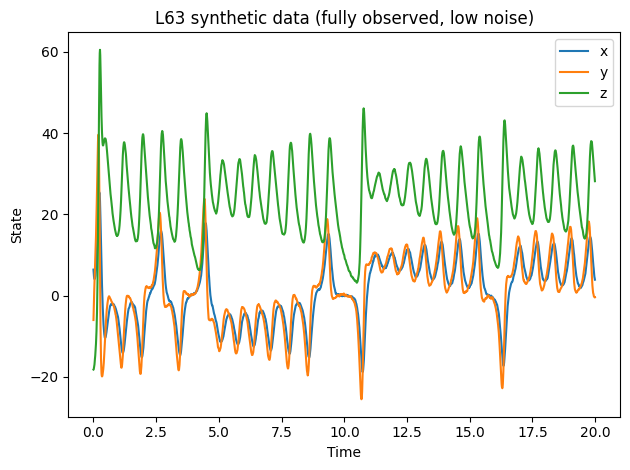

In [8]:
true_rho = 28.0
obs_times = jnp.arange(start=0.0, stop=20.0, step=0.01)  # high-frequency
rng_key = jr.PRNGKey(0)
data_init_key, data_solver_key, mcmc_key = jr.split(rng_key, 3)

true_params = {"rho": jnp.array(true_rho)}
predictive = Predictive(
    l63_fully_observed_model,
    params=true_params,
    num_samples=1,
    exclude_deterministic=False,
)

context = Context(observations=Trajectory(times=obs_times))
with SDESimulator(key=data_solver_key):
    with Condition(context):
        synthetic = predictive(data_init_key)

obs_values = synthetic["observations"].squeeze(0)  # (T, 3)
states = synthetic["states"].squeeze(0)  # (T, 3)
observation_trajectory = Trajectory(times=obs_times, values=obs_values)

print(f"Observations shape: {obs_values.shape}")
print(f"True rho: {true_rho}")

# plot the data
obs_t = jnp.asarray(obs_times).squeeze()
for i, label in enumerate(["x", "y", "z"]):
    plt.plot(obs_t, jnp.asarray(obs_values)[:, i], label=label)
plt.xlabel("Time")
plt.ylabel("State")
plt.legend()
plt.title("L63 synthetic data (fully observed, low noise)")
plt.tight_layout()
plt.show()


In [9]:
num_samples = 200
num_warmup = 200


## Approach 2: Discretizer + DiscreteTimeSimulator + Dirac + NUTS

Discretizes the SDE via Euler-Maruyama, uses `DiracIdentityObservation` (y_t = x_t), and runs NUTS. No filter needed.

In [10]:
# For Dirac, we condition on the states (or low-noise obs as proxy for states)
# With low noise, obs_values ≈ states; Dirac treats them as exact.

def data_conditioned_model_dirac():
    context = Context(observations=observation_trajectory)
    with DiscreteTimeSimulator():
        with Discretizer():
            with Condition(context):
                return l63_fully_observed_model(dirac_observation=True)

In [11]:
mcmc_dirac = MCMC(NUTS(data_conditioned_model_dirac), num_samples=num_samples, num_warmup=num_warmup)

mcmc_key_dirac = jr.PRNGKey(1)
t0 = time.perf_counter()
mcmc_dirac.run(mcmc_key_dirac)
t_dirac = time.perf_counter() - t0

posterior_dirac = mcmc_dirac.get_samples()
print(f"Discretizer + Dirac + NUTS: {t_dirac:.2f} seconds")

ValueError: Incompatible shapes for broadcasting: shapes=[(1999, 3), (1999,)]

## Approach 1: EnKF + NUTS

Uses the continuous-discrete filter (EnKF) to approximate the marginal likelihood, then NUTS MCMC.

In [12]:
def data_conditioned_model_enkf():
    context = Context(observations=observation_trajectory)
    with FilterBasedMarginalLogLikelihood(filter_type="EnKF"):
        with Condition(context):
            return l63_fully_observed_model(dirac_observation=False)

In [13]:
mcmc_enkf = MCMC(NUTS(data_conditioned_model_enkf), num_samples=num_samples, num_warmup=num_warmup)

t0 = time.perf_counter()
mcmc_enkf.run(mcmc_key)
t_enkf = time.perf_counter() - t0

posterior_enkf = mcmc_enkf.get_samples()
print(f"EnKF + NUTS: {t_enkf:.2f} seconds")

warmup:   3%|▎         | 13/400 [00:05<02:47,  2.31it/s, 1 steps of size 7.34e-04. acc. prob=0.57]


KeyboardInterrupt: 

## Comparison

In [ ]:
print("=" * 50)
print("TIMING")
print("=" * 50)
print(f"EnKF + NUTS:                    {t_enkf:.2f} s")
print(f"Discretizer + Dirac + NUTS:     {t_dirac:.2f} s")
print(f"Speedup: {t_enkf / t_dirac:.1f}x")
print("=" * 50)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

az.plot_posterior(
    posterior_enkf,
    var_names=["rho"],
    hdi_prob=0.95,
    ref_val=true_rho,
    ax=axes[0],
)
axes[0].set_title("EnKF + NUTS")

az.plot_posterior(
    posterior_dirac,
    var_names=["rho"],
    hdi_prob=0.95,
    ref_val=true_rho,
    ax=axes[1],
)
axes[1].set_title("Discretizer + Dirac + NUTS")

plt.tight_layout()
plt.show()

In [ ]:
print("Posterior summary (rho):")
print("EnKF:")
print(f"  mean = {float(posterior_enkf['rho'].mean()):.2f}, std = {float(posterior_enkf['rho'].std()):.2f}")
print("Dirac:")
print(f"  mean = {float(posterior_dirac['rho'].mean()):.2f}, std = {float(posterior_dirac['rho'].std()):.2f}")
print(f"\nTrue rho: {true_rho}")